# E-Scooter — Modèles de choix discret (Biogeme)
## Variable dépendante : accélérer (1) vs décélérer/maintenir (0)

| Etape | Contenu |
|-------|---------|
| 1 | Imports |
| 2 | Chargement |
| 3 | Reduction 1 Hz |
| 4 | Variable dependante delta_speed |
| 5 | Standardisation + effets fixes |
| 6 | Helper Biogeme |
| 7 | M0 : null model |
| 8 | M1 : pietons + distance |
| 9 | M2 : + largeur route |
| 10 | M3 : complet + effets fixes |
| 11 | Comparaison modeles |
| 12 | Forest plot coefficients |
| 13 | Effets marginaux |
| 14 | Courbes probabilite predite |
| 15 | Synthese |


## 1 · Imports & configuration

In [3]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os
import biogeme.biogeme as bio
import biogeme.database as db
import biogeme.expressions as Variables
import biogeme.expressions as ex
from biogeme.expressions import Beta, Variable, bioDraws, MonteCarlo, exp, log, Elem, bioNormalCdf
import biogeme.models as models
import biogeme.results_processing as rp
from biogeme.parameters import Parameters

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 130,
                     'axes.spines.top': False,
                     'axes.spines.right': False})

DATASET_PATH = '/Volumes/My Passport/NEWMOB/clean_dataset.csv'  # meme dossier que ce notebook
FPS          = 30                   # frames par seconde
COLOR_ACC    = '#2E86AB'
COLOR_DEC    = '#E84855'


## 2 · Chargement du dataset

In [4]:
df_raw = pd.read_csv(DATASET_PATH)
print(f'Dataset brut : {df_raw.shape[0]:,} lignes x {df_raw.shape[1]} colonnes')
print(f'Trajets      : {df_raw["source"].nunique()}')
display(df_raw.head(4))
print()
print('Valeurs manquantes :')
display(df_raw.isna().sum().to_frame('n_missing'))


Dataset brut : 877,682 lignes x 29 colonnes
Trajets      : 25


,source,frame,track_id,user_type_yolo,distance_smooth_m,encounter_status,speed_kmh,gyrz_deg_s,n_pedestrians,INTERACTION_TYPE,...,is_weekend,time_of_day,month,season,genre,age,experience,nb_trajets,distance_km,rider_id
0,332t_2023-04-26 12_05_55_332t_21_27_22_15,201,23,pedestrian,12.954853,coded,11.76523,21.730032,1,NaN,...,False,Morning,4,Spring,female,29.0,>2,57.0,241.603,332t_vague2
1,332t_2023-04-26 12_05_55_332t_21_27_22_15,201,23,pedestrian,12.954853,coded,11.76523,21.730032,1,NaN,...,False,Morning,4,Spring,female,29.0,>2,57.0,241.603,332t_vague2
2,332t_2023-04-26 12_05_55_332t_21_27_22_15,201,23,pedestrian,12.954853,coded,11.76523,21.730032,1,NaN,...,False,Morning,4,Spring,female,29.0,>2,57.0,241.603,332t_vague2
3,332t_2023-04-26 12_05_55_332t_21_27_22_15,201,23,pedestrian,12.954853,coded,11.76523,21.205030,1,NaN,...,False,Morning,4,Spring,female,29.0,>2,57.0,241.603,332t_vague2



Valeurs manquantes :


,n_missing
source,0
frame,0
track_id,0
user_type_yolo,0
distance_smooth_m,0
encounter_status,0
speed_kmh,17964
gyrz_deg_s,17964
n_pedestrians,0
INTERACTION_TYPE,877682


## 3 · Reduction a 1 Hz

Le dataset est echantillonne a 30 FPS. On regroupe par **seconde** (`second = frame // 30`) :

| Variable | Agregation | Justification |
|----------|-----------|---------------|
| `speed_kmh` | `mean` | vitesse representative |
| `n_pedestrians` | `max` | situation la plus contraignante |
| `distance_smooth_m` | `min` | distance la plus proche |
| `road_width_perp_m` | `mean` | caracteristique stable |


In [5]:
df_raw['second'] = df_raw['frame'] // FPS

df_1hz = (
    df_raw
    .groupby(['source', 'second'])
    .agg(
        speed_kmh         = ('speed_kmh',          'mean'),
        n_pedestrians     = ('n_pedestrians',       'max'),
        distance_smooth_m = ('distance_smooth_m',   'min'),
        road_width_perp_m = ('road_width_perp_m',   'mean'),
        # ── Variables temporelles (constantes par trajet → first) ──────────
        hour              = ('hour',                'first'),
        day_of_week       = ('day_of_week',         'first'),
        day_name          = ('day_name',            'first'),
        is_weekend        = ('is_weekend',          'first'),
        time_of_day       = ('time_of_day',         'first'),
        month             = ('month',               'first'),
        season            = ('season',              'first'),
        genre             = ('genre',               'first'),
        age               = ('age',                 'first'),
        experience        = ('experience',          'first'),
        distance_km      = ('distance_km',        'first')  


    )
    .reset_index()
    .sort_values(['source', 'second'])
    .reset_index(drop=True)
)

print(f'Après réduction 1 Hz : {len(df_1hz):,} secondes — {df_1hz["source"].nunique()} trajets')
display(df_1hz.describe().round(2))

Après réduction 1 Hz : 1,068 secondes — 25 trajets


,second,speed_kmh,n_pedestrians,distance_smooth_m,road_width_perp_m,hour,day_of_week,month,age,distance_km
count,1068.00,1038.00,1068.00,1068.00,1020.00,1068.00,1068.00,1068.00,1010.00,1010.00
mean,49.45,13.74,4.00,5.71,18.08,11.10,3.05,6.99,36.36,155.49
std,43.55,7.03,2.98,3.11,14.58,3.37,1.44,2.37,11.93,90.86
min,0.00,2.02,1.00,0.71,0.04,5.00,0.00,4.00,21.00,10.00
25%,15.00,8.91,2.00,3.39,8.59,9.00,2.00,5.00,29.00,55.69
50%,36.00,11.27,3.00,4.34,12.09,11.00,3.00,6.00,30.00,142.27
75%,72.00,16.84,6.00,7.10,22.95,13.00,4.00,10.00,52.00,241.60
max,191.00,31.68,15.00,14.98,103.50,20.00,6.00,10.00,55.00,323.21


## 4 · Variable dependante : acceleration/deceleration

**Definition :** `delta_speed = speed_kmh(t+1) - speed_kmh(t)` calcule par trajet.

- `delta_speed > 0`  ->  **accelerer** (choice = 1)
- `delta_speed <= 0` ->  **decelerer / maintenir** (choice = 0)

La derniere seconde de chaque trajet est supprimee (pas de t+1).


Observations totales : 989
  Accelerer (1) : 477  (48.2 %)
  Decelerer (0) : 512  (51.8 %)


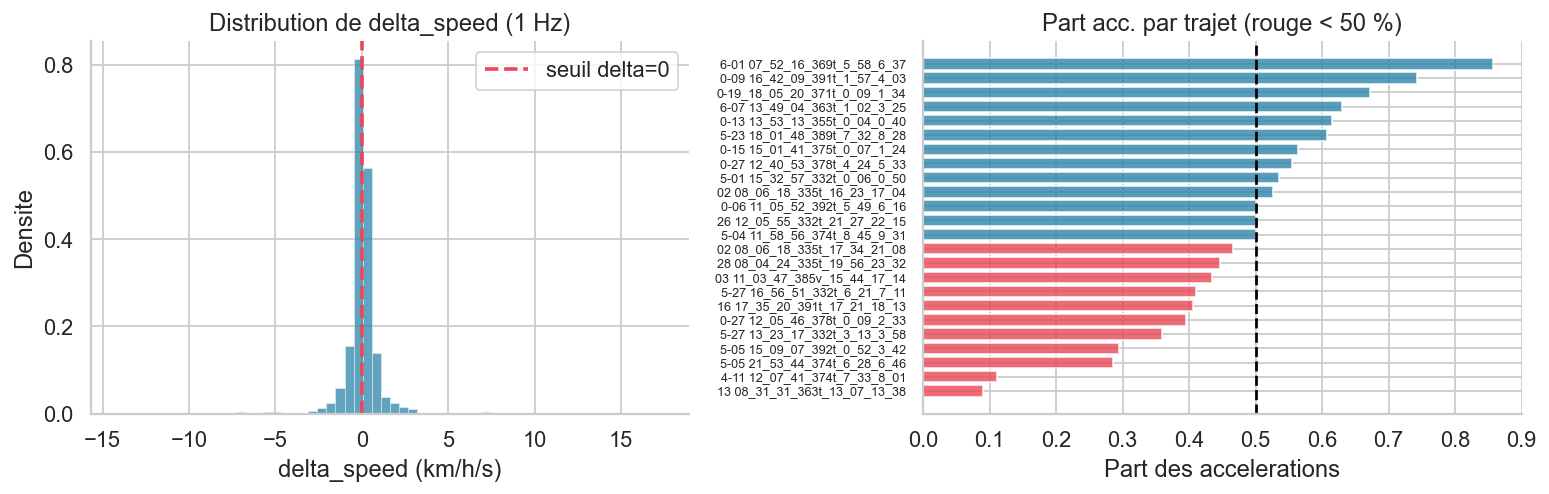

In [9]:
df_1hz['speed_next']  = df_1hz.groupby('source')['speed_kmh'].shift(-1)
df_1hz['delta_speed'] = df_1hz['speed_next'] - df_1hz['speed_kmh']

df_model = df_1hz.dropna(subset=['delta_speed', 'speed_kmh',
                                  'n_pedestrians', 'distance_smooth_m',
                                  'road_width_perp_m']).copy()

df_model['choice'] = (df_model['delta_speed'] > 0).astype(int)

n_acc = df_model['choice'].sum()
n_dec = len(df_model) - n_acc
print(f'Observations totales : {len(df_model):,}')
print(f'  Accelerer (1) : {n_acc:,}  ({n_acc/len(df_model)*100:.1f} %)')
print(f'  Decelerer (0) : {n_dec:,}  ({n_dec/len(df_model)*100:.1f} %)')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.hist(df_model['delta_speed'], bins=60, color=COLOR_ACC, alpha=0.75,
        edgecolor='white', lw=0.3, density=True)
ax.axvline(0, color=COLOR_DEC, lw=2, ls='--', label='seuil delta=0')
ax.set_xlabel('delta_speed (km/h/s)')
ax.set_ylabel('Densite')
ax.set_title('Distribution de delta_speed (1 Hz)')
ax.legend()

ax = axes[1]
share = df_model.groupby('source')['choice'].mean().sort_values()
colors_bar = [COLOR_DEC if v < 0.5 else COLOR_ACC for v in share.values]
ax.barh(range(len(share)), share.values, color=colors_bar, alpha=0.8)
ax.axvline(0.5, color='black', lw=1.5, ls='--')
ax.set_yticks(range(len(share)))
ax.set_yticklabels([s[-28:] for s in share.index], fontsize=7)
ax.set_xlabel('Part des accelerations')
ax.set_title('Part acc. par trajet (rouge < 50 %)')
plt.tight_layout()
plt.show()


## 5 · Standardisation & création de dummy

**Variables standardisees** (`z = (x - mu) / sigma`) : coefficients comparables.


In [10]:
# ── Variables continues : z-scores ───────────────────────────────────────────
cont_vars = ['speed_kmh', 'n_pedestrians', 'distance_smooth_m', 'road_width_perp_m', 'hour']

# 'hour' est continue (0–23) → z-score comme les autres
# On l'inclut uniquement si la colonne est présente et non-vide
cont_vars = [v for v in cont_vars if v in df_model.columns
             and df_model[v].notna().any()]

means_ = df_model[cont_vars].mean()
stds_  = df_model[cont_vars].std()

for v in cont_vars:
    df_model[f'z_{v}'] = (df_model[v] - means_[v]) / stds_[v]

print('Statistiques des z-scores (doivent être ~mean=0, std=1) :')
display(df_model[[f'z_{v}' for v in cont_vars]].describe().round(3))


# ── Variables catégorielles temporelles : dummies ─────────────────────────────
# time_of_day  : Morning / Afternoon / Evening / Night   → ref = Morning
# day_name     : Monday … Sunday                         → ref = Monday
# season       : Spring / Summer / Autumn / Winter       → ref = Spring
# is_weekend   : bool True/False                         → ref = False (weekday)
#
# drop_first=True supprime la modalité de référence pour éviter la colinéarité.
# Les références choisies correspondent aux modalités les plus fréquentes /
# les plus neutres — ajuster si besoin.

CAT_TEMPORAL = {
    'time_of_day': 'Morning',
    'day_name':    'Monday',
    'season':      'Spring',
    'is_weekend':  False,
    'genre':'male',
    'experience':'0.5-1'
}

temporal_dummy_cols = []

for col, ref in CAT_TEMPORAL.items():
    if col not in df_model.columns:
        print(f'  ⚠  {col} absent — ignoré')
        continue
    if df_model[col].notna().sum() == 0:
        print(f'  ⚠  {col} entièrement vide — ignoré')
        continue

    # Vérifie que la référence existe dans les données
    uniq = df_model[col].dropna().unique()
    if ref not in uniq:
        print(f'  ⚠  {col} : référence {ref!r} absente des données '
              f'(valeurs présentes : {sorted(uniq)})')
        # On bascule sur drop_first=True par défaut
        dummies = pd.get_dummies(df_model[col], prefix=col, drop_first=True)
    else:
        # Réordonne pour que la référence soit en première position → drop_first retire bien la ref
        cats = [ref] + [v for v in sorted(uniq) if v != ref]
        dummies = pd.get_dummies(
            pd.Categorical(df_model[col], categories=cats, ordered=False),
            prefix=col,
            drop_first=True,   # supprime la modalité de référence
        )

    dummies = dummies.astype(int)
    df_model = pd.concat([df_model.reset_index(drop=True),
                           dummies.reset_index(drop=True)], axis=1)
    temporal_dummy_cols.extend(dummies.columns.tolist())
    print(f'  {col:15s} → {len(dummies.columns)} dummies  '
          f'(réf = {ref!r})  |  {dummies.columns.tolist()}')

print(f'\nDummies temporels ajoutés : {len(temporal_dummy_cols)}')
print(f'Colonnes : {temporal_dummy_cols}')


# ── Effets fixes trajets ──────────────────────────────────────────────────────
traj_dummies = pd.get_dummies(df_model['source'], prefix='traj', drop_first=True)
df_model     = pd.concat([df_model.reset_index(drop=True),
                           traj_dummies.astype(int).reset_index(drop=True)], axis=1)
trajet_cols  = traj_dummies.columns.tolist()
print(f'\nEffets fixes trajets : {len(trajet_cols)}')


# ── Récapitulatif des blocs de variables ──────────────────────────────────────
print('\n' + '=' * 55)
print('Récapitulatif des blocs de variables')
print('=' * 55)
print(f'  Z-scores continus   : {[f"z_{v}" for v in cont_vars]}')
print(f'  Dummies temporels   : {temporal_dummy_cols}')
print(f'  Effets fixes trajets: {len(trajet_cols)} colonnes')
print(f'\n  Total colonnes model: {df_model.shape[1]}')
print(f'  Total lignes        : {df_model.shape[0]}')

Statistiques des z-scores (doivent être ~mean=0, std=1) :


,z_speed_kmh,z_n_pedestrians,z_distance_smooth_m,z_road_width_perp_m,z_hour
count,989.000,989.000,989.000,989.000,989.000
mean,-0.000,0.000,-0.000,-0.000,-0.000
std,1.000,1.000,1.000,1.000,1.000
min,-1.667,-1.037,-1.602,-1.232,-1.789
25%,-0.699,-0.704,-0.739,-0.646,-0.598
50%,-0.351,-0.372,-0.440,-0.415,-0.002
75%,0.490,0.625,0.423,0.334,0.593
max,2.518,3.616,2.999,5.847,2.678


  time_of_day     → 3 dummies  (réf = 'Morning')  |  ['time_of_day_Afternoon', 'time_of_day_Evening', 'time_of_day_Night']
  day_name        → 6 dummies  (réf = 'Monday')  |  ['day_name_Friday', 'day_name_Saturday', 'day_name_Sunday', 'day_name_Thursday', 'day_name_Tuesday', 'day_name_Wednesday']
  season          → 2 dummies  (réf = 'Spring')  |  ['season_Autumn', 'season_Summer']
  is_weekend      → 1 dummies  (réf = False)  |  ['is_weekend_True']
  genre           → 1 dummies  (réf = 'male')  |  ['genre_female']
  experience      → 3 dummies  (réf = '0.5-1')  |  ['experience_1-2', 'experience_<0.5', 'experience_>2']

Dummies temporels ajoutés : 16
Colonnes : ['time_of_day_Afternoon', 'time_of_day_Evening', 'time_of_day_Night', 'day_name_Friday', 'day_name_Saturday', 'day_name_Sunday', 'day_name_Thursday', 'day_name_Tuesday', 'day_name_Wednesday', 'season_Autumn', 'season_Summer', 'is_weekend_True', 'genre_female', 'experience_1-2', 'experience_<0.5', 'experience_>2']

Effets fixes t

# Betas and variables

In [11]:
import re# Beta _acc pour les variables temporelles (dummies + z_hour)
# Colonnes concernées : temporal_dummy_cols + z_hour (si présent)

def normalize(name: str) -> str:
    clean = name.lower()
    clean = re.sub(r'[^a-z0-9]+', '_', clean)
    clean = re.sub(r'_+', '_', clean)
    clean = clean.strip('_')
    if re.match(r'^[0-9]', clean):
        clean = "var_" + clean
    return clean


temporal_model_cols = temporal_dummy_cols.copy()
if 'z_hour' in df_model.columns:
    temporal_model_cols.append('z_hour')

for col in temporal_model_cols:
    clean_name = normalize(col)

    if clean_name == "":
        print(f"Skip (empty after cleaning): {col}")
        continue

    if clean_name not in locals():
        exec(f"{clean_name} = Variable({repr(col)})")

    beta_var_name = f"beta_{clean_name}_acc"

    if not beta_var_name.isidentifier():
        print(f"Skip beta (invalid identifier): {beta_var_name}")
        continue

    if beta_var_name in locals():
        continue

    exec(f"{beta_var_name} = Beta({repr(beta_var_name)}, 0, None, None, 0)")
    print(f"  ✔  {beta_var_name}")

  ✔  beta_time_of_day_afternoon_acc
  ✔  beta_time_of_day_evening_acc
  ✔  beta_time_of_day_night_acc
  ✔  beta_day_name_friday_acc
  ✔  beta_day_name_saturday_acc
  ✔  beta_day_name_sunday_acc
  ✔  beta_day_name_thursday_acc
  ✔  beta_day_name_tuesday_acc
  ✔  beta_day_name_wednesday_acc
  ✔  beta_season_autumn_acc
  ✔  beta_season_summer_acc
  ✔  beta_is_weekend_true_acc
  ✔  beta_genre_female_acc
  ✔  beta_experience_1_2_acc
  ✔  beta_experience_0_5_acc
  ✔  beta_experience_2_acc
  ✔  beta_z_hour_acc


In [12]:
# ── Dictionnaire de correspondance Beta → LaTeX ─────────────────────────────
# À définir UNE FOIS en haut du notebook, à compléter au fur et à mesure
BETA_LABELS = {
    'ASC':      r'\text{ASC}',
    'beta_time_of_day_afternoon_acc':   r'\beta_{\text{Afternoon}',

    # ajouter ici les nouveaux betas au fur et à mesure
}

def _beta_to_latex(beta_name):
    """Retourne le label LaTeX pour un beta, ou un fallback générique."""
    if beta_name in BETA_LABELS:
        return f'${BETA_LABELS[beta_name]}$'
    # fallback : b_myvar → $\beta_{\text{myvar}}$
    m = re.match(r'b_(.+)', beta_name)
    if m:
        return rf'$\beta_{{\text{{{m.group(1)}}}}}$'
    return rf'$\beta_{{\text{{{beta_name}}}}}$'


def _df_to_latex_params(df, model_name):
    """Génère un tableau LaTeX des paramètres estimés."""
    col_value   = next(c for c in df.columns if 'value'   in c.lower())
    col_stderr  = next(c for c in df.columns if 'std'     in c.lower())
    col_tstat   = next(c for c in df.columns if 't-stat'  in c.lower() or 'tstat' in c.lower())
    col_pvalue  = next(c for c in df.columns if 'p-value' in c.lower() or 'pvalue' in c.lower())

    lines = [
        r'\begin{table}[h!]\centering\small',
        r'\begin{tabular}{lrrrr}',
        r'\hline\hline',
        r'Paramètre & Valeur & Std. err. rob. & $t$-stat. rob. & $p$-valeur \\',
        r'\hline',
    ]
    for idx, row in df.iterrows():
        label = _beta_to_latex(str(idx))
        sig   = (r' $^{***}$' if row[col_pvalue] < .001 else
                 r' $^{**}$'  if row[col_pvalue] < .01  else
                 r' $^{*}$'   if row[col_pvalue] < .05  else '')
        lines.append(
            f'{label} & {row[col_value]:.4f} & {row[col_stderr]:.4f}'
            f' & {row[col_tstat]:.3f} & {row[col_pvalue]:.4f}{sig} \\\\'
        )
    lines += [
        r'\hline\hline',
        r'\end{tabular}',
        rf'\caption{{Paramètres estimés — \texttt{{{model_name}}}}}',
        rf'\label{{tab:{model_name}_params}}',
        r'\end{table}',
    ]
    return '\n'.join(lines)


def _metrics_to_latex(metrics, metrics_const, lrt_stat, lrt_df, lrt_p, model_name):
    """Génère un tableau LaTeX des statistiques générales du modèle."""
    sig = (r'$^{***}$' if lrt_p < .001 else r'$^{**}$' if lrt_p < .01
           else r'$^{*}$' if lrt_p < .05 else '')
    rows = [
        (r'$N$',                                    f'{metrics["N"]}'),
        (r'$K$',                                    f'{metrics["K"]}'),
        (r'$\mathcal{L}(0)$',                       f'{metrics["LL_null"]:.2f}'),
        (r'$\mathcal{L}(\text{cst})$',              f'{metrics_const["LL_final"]:.2f}'),
        (r'$\mathcal{L}(\hat{\beta})$',             f'{metrics["LL_final"]:.2f}'),
        (r'$\rho^2$',                               f'{metrics["rho2"]:.4f}'),
        (r'$\bar{\rho}^2$',                         f'{metrics["rho2_bar"]:.4f}'),
        (r'AIC',                                    f'{metrics["AIC"]:.2f}'),
        (r'BIC',                                    f'{metrics["BIC"]:.2f}'),
        (rf'LRT $\chi^2({lrt_df})$ vs cst',        f'{lrt_stat:.2f}{sig}'),
        (r'$p$-valeur LRT',                         f'{lrt_p:.4f}'),
    ]
    lines = [
        r'\begin{table}[h!]\centering\small',
        r'\begin{tabular}{lr}',
        r'\hline\hline',
        r'Statistique & Valeur \\',
        r'\hline',
    ] + [rf'{label} & {val} \\' for label, val in rows] + [
        r'\hline\hline',
        r'\end{tabular}',
        rf'\caption{{Statistiques du modèle — \texttt{{{model_name}}}}}',
        rf'\label{{tab:{model_name}_stats}}',
        r'\end{table}',
    ]
    return '\n'.join(lines)

## 6 · Fonction utilitaire Biogeme

Encapsule l'estimation d'un **logit binaire** :
- Utilite alternative 1 (accelerer) : `V1 = ASC + sum(beta_k * x_k)`
- Utilite alternative 0 (decelerer) : `V0 = 0` (reference)
- Retourne : resultats Biogeme, tableau de coefficients, metriques (rho2, AIC, BIC)


In [13]:
import os, shutil
import numpy as np
import biogeme.biogeme as bio
import biogeme.database as db
import biogeme.expressions as ex
import biogeme.models as models
import biogeme.results as rp
from biogeme.parameters import Parameters


def _get_out_dir(model_name):
    base = os.path.join('model_results', model_name)
    if not os.path.exists(base):
        return base
    i = 2
    while os.path.exists(f'{base}_v{i}'):
        i += 1
    return f'{base}_v{i}'



def _extract_vars(utility_expr):
    """Retourne les noms de colonnes-données (Variable) dans l'expression."""
    vars_ = []
    if isinstance(utility_expr, ex.Variable):
        vars_.append(utility_expr.name)
    for child in getattr(utility_expr, 'children', []):
        vars_.extend(_extract_vars(child))
    return list(dict.fromkeys(vars_))


def _extract_betas(expr):
    """Retourne tous les nœuds Beta dans l'expression (récursif)."""
    betas = []
    if isinstance(expr, ex.Beta):
        betas.append(expr)
    for child in getattr(expr, 'children', []):
        betas.extend(_extract_betas(child))
    return betas


def _run_biogeme(database, logprob, model_name, params_bio):
    m = bio.BIOGEME(database, logprob, parameters=params_bio)
    m.model_name = model_name
    m.calculate_null_loglikelihood({1: ex.Numeric(1), 0: ex.Numeric(1)})
    res = m.estimate()
    return m, res   # ← tuple (m, res)
def run_logit(df_est, utility, model_name, asc=None):

    # ── 1. Données ─────────────────────────────────────────────────────────
    utility_vars = _extract_vars(utility)
    cols = ['choice'] + utility_vars
    before = len(df_est)
    data = df_est[cols].dropna().copy()
    dropped = before - len(data)
    if dropped:
        print(f'[{model_name}] ⚠ {dropped} lignes supprimées (NaN)')
    # après
    for col in data.columns:
        if pd.api.types.is_bool_dtype(data[col]):
            data[col] = data[col].astype(int)
    N = len(data)
    database = db.Database(model_name, data)

    # ── 2. Paramètres Biogeme ──────────────────────────────────────────────
    params_bio = Parameters()
    params_bio.set_value('generate_html',   True)
    params_bio.set_value('generate_yaml',   False)
    params_bio.set_value('generate_netcdf', False)
    V0 = ex.Numeric(0)

    # ── 3. Modèle constant (ASC seul) ──────────────────────────────────────
    const_name = f'{model_name}_constant'
    if asc is None:
        all_betas = _extract_betas(utility)
        asc_betas = [b for b in all_betas if b.name.lower().startswith('asc')]
        asc = asc_betas[0] if asc_betas else ex.Beta('ASC', 0, None, None, 0)

    logprob_const = models.loglogit({1: asc, 0: V0}, None, ex.Variable('choice'))
    db_const      = db.Database(const_name, data)
    _, res_const  = _run_biogeme(db_const, logprob_const, const_name, params_bio)

    ll_const = res_const.raw_estimation_results.final_log_likelihood
    ll_null  = res_const.raw_estimation_results.null_log_likelihood
    k_const  = 1

    # ── 4. Modèle principal ─────────────────────────────────────────────────
    logprob    = models.loglogit({1: utility, 0: V0}, None, ex.Variable('choice'))
    m_main, res = _run_biogeme(database, logprob, model_name, params_bio)

    # ── 5. Métriques ────────────────────────────────────────────────────────
    final_ll = res.raw_estimation_results.final_log_likelihood
    k        = len(res.get_beta_values())

    def _metrics(ll_f, ll_0, n, nk, name):
        rho2     = 1 - ll_f / ll_0         if ll_0 != 0 else float('nan')
        rho2_bar = 1 - (ll_f - nk) / ll_0 if ll_0 != 0 else float('nan')
        aic      = -2 * ll_f + 2 * nk
        bic      = -2 * ll_f + nk * np.log(n)
        return dict(Model=name, N=n, K=nk,
                    LL_null=round(ll_0, 2),  LL_final=round(ll_f, 2),
                    rho2=round(rho2, 4),     rho2_bar=round(rho2_bar, 4),
                    AIC=round(aic, 2),       BIC=round(bic, 2))

    metrics_const = _metrics(ll_const, ll_null, N, k_const, const_name)
    metrics       = _metrics(final_ll, ll_null, N, k,       model_name)

    from scipy import stats as sp_stats
    lrt_stat = -2 * (ll_const - final_ll)
    lrt_df   = k - k_const
    lrt_p    = sp_stats.chi2.sf(lrt_stat, lrt_df)

    metrics['LRT_stat'] = round(lrt_stat, 2)
    metrics['LRT_df']   = lrt_df
    metrics['LRT_p']    = round(lrt_p, 4)

    # ── 6. params_df ────────────────────────────────────────────────────────
    params_df = res.get_estimated_parameters()
    params_df.columns = [c.strip() for c in params_df.columns]

   # ── 7. Sauvegarde (après params_df et metrics) ──────────────────────────
    # ── 7. Sauvegarde (après params_df et metrics) ──────────────────────────
    out_dir = _get_out_dir(model_name)
    os.makedirs(out_dir)
    with open(os.path.join(out_dir, f'{model_name}_params.tex'), 'w') as f:
        f.write(_df_to_latex_params(params_df, model_name))
    with open(os.path.join(out_dir, f'{model_name}_stats.tex'), 'w') as f:
        f.write(_metrics_to_latex(metrics, metrics_const,
                                   lrt_stat, lrt_df, lrt_p, model_name))

    # Déplacement des fichiers générés par Biogeme vers out_dir
    # Biogeme génère parfois les fichiers avec un préfixe '__'
    for name in [model_name, const_name]:
        for prefix in ['', '__']:
            for ext in ['.iter', '.html']:
                fname = f'{prefix}{name}{ext}'
                if os.path.exists(fname):
                    shutil.move(fname, os.path.join(out_dir, fname))

    # Déplacement des fichiers générés par Biogeme vers out_dir
    for fname in [
        f'{model_name}.iter',
        f'{model_name}.html',
        f'{const_name}.iter',
        f'{const_name}.html',
    ]:
        if os.path.exists(fname):
            shutil.move(fname, os.path.join(out_dir, fname))
    # ── 8. Affichage ────────────────────────────────────────────────────────
    print(f'\n{"="*65}')
    print(f'  Modèle constant  ({const_name})')
    print(f'  LL={ll_const:.2f}  rho2={metrics_const["rho2"]:.4f}'
          f'  AIC={metrics_const["AIC"]:.1f}')
    print(f'{"─"*65}')
    print(f'  Modèle principal ({model_name})')
    print(f'  N={N}  K={k}  LL={final_ll:.2f}  rho2={metrics["rho2"]:.4f}'
          f'  AIC={metrics["AIC"]:.1f}')
    print(f'{"─"*65}')
    sig = (' ***' if lrt_p < .001 else ' **' if lrt_p < .01
           else ' *'   if lrt_p < .05  else ' (n.s.)')
    print(f'  LRT vs constant : χ²({lrt_df})={lrt_stat:.2f}  p={lrt_p:.4f}{sig}')
    print(f'{"="*65}')

    display(params_df.style.format({
        'Value':           '{:.4f}',
        'Robust std err.': '{:.4f}',
        'Robust t-stat.':  '{:.3f}',
        'Robust p-value':  '{:.4f}',
    }))

    return res, params_df, metrics, metrics_const

## 7 · Modele 0 — Constante seule (null model)

Seul l'ASC capture la propension marginale a accelerer. Sert de reference pour rho2.

In [14]:
all_metrics = []
all_params  = {}
all_res     = {}

# ── M0 : modèle nul (ASC seul) ─────────────────────────────────────────────
# Pas besoin d'appeler run_logit ici — le modèle constant est estimé
# automatiquement en interne à chaque appel. On peut quand même le stocker
# si on veut ses métriques dans le tableau comparatif.

ASC = ex.Beta('ASC', 0, None, None, 0)

res0, p0, m0, m0_const = run_logit(df_model, ASC, 'M0_null')
all_metrics.append(m0_const)   # modèle constant (ASC seul) = notre M0
all_metrics.append(m0)         # modèle M0_null (idem ici, redondant mais cohérent)
all_params['M0_null'] = p0
all_res['M0_null']    = res0



  Modèle constant  (M0_null_constant)
  LL=-684.90  rho2=0.0009  AIC=1371.8
─────────────────────────────────────────────────────────────────
  Modèle principal (M0_null)
  N=989  K=1  LL=-684.90  rho2=0.0009  AIC=1371.8
─────────────────────────────────────────────────────────────────
  LRT vs constant : χ²(0)=-0.00  p=nan (n.s.)


,Name,Value,Robust std err.,Robust t-stat.,Robust p-value
0,ASC,-0.0708,0.0636,-1.113,0.2658


## 8 · Modele 1 — Pietons + Distance

Variables :
- `z_n_pedestrians` : nombre de pietons a moins de 15 m (z-score)
- `z_distance_smooth_m` : distance au pieton le plus proche (z-score)

In [15]:
# ── M1 : piétons + distance ─────────────────────────────────────────────────
ASC       = ex.Beta('ASC',            0, None, None, 0)
B_ped     = ex.Beta('b_n_pedestrians', 0, None, None, 0)
B_dist    = ex.Beta('b_distance',      0, None, None, 0)

utility_M1 = (ASC
              + B_ped  * ex.Variable('z_n_pedestrians')
              + B_dist * ex.Variable('z_distance_smooth_m'))

res1, p1, m1, _ = run_logit(df_model, utility_M1, 'M1_ped_dist')
all_metrics.append(m1)
all_params['M1_ped_dist'] = p1
all_res['M1_ped_dist']    = res1


  Modèle constant  (M1_ped_dist_constant)
  LL=-684.90  rho2=0.0009  AIC=1371.8
─────────────────────────────────────────────────────────────────
  Modèle principal (M1_ped_dist)
  N=989  K=3  LL=-679.08  rho2=0.0094  AIC=1364.2
─────────────────────────────────────────────────────────────────
  LRT vs constant : χ²(2)=11.65  p=0.0030 **


,Name,Value,Robust std err.,Robust t-stat.,Robust p-value
0,ASC,-0.0726,0.0640,-1.134,0.2566
1,b_n_pedestrians,-0.2354,0.0710,-3.314,0.0009
2,b_distance,-0.0499,0.0694,-0.719,0.4724


## 9 · Modele 2 — + Largeur de route

Ajoute : `z_road_width_perp_m` (largeur perpendiculaire de la voirie, z-score)

In [150]:
# ── M1 : piétons + distance ─────────────────────────────────────────────────
ASC       = ex.Beta('ASC',            0, None, None, 0)
B_ped     = ex.Beta('b_n_pedestrians', 0, None, None, 0)
B_weekday  = ex.Beta('b_weekday',      0, None, None, 0)

utility_M1 = (ASC
              + B_ped  * ex.Variable('z_n_pedestrians')
              + beta_genre_female_acc * ex.Variable('genre_female'))

res1, p1, m1, _ = run_logit(df_model, utility_M1, 'M2_ped_dist')
all_metrics.append(m1)
all_params['M2_ped_dist'] = p1
all_res['M2_ped_dist']    = res1


  Modèle constant  (M2_ped_dist_constant)
  LL=-684.90  rho2=0.0009  AIC=1371.8
─────────────────────────────────────────────────────────────────
  Modèle principal (M2_ped_dist)
  N=989  K=3  LL=-676.36  rho2=0.0134  AIC=1358.7
─────────────────────────────────────────────────────────────────
  LRT vs constant : χ²(2)=17.09  p=0.0002 ***


,Name,Value,Robust std err.,Robust t-stat.,Robust p-value
0,ASC,0.0947,0.0938,1.009,0.3131
1,b_n_pedestrians,-0.1559,0.0694,-2.244,0.0248
2,beta_genre_female_acc,-0.3337,0.1369,-2.438,0.0148


## 10 · Modele 3 — Complet + effets fixes trajets

Controle l'heterogeneite non observee entre participants (vitesse de croisiere, style de conduite, environnement).

> **Note** : si un trajet a tres peu d'observations, son indicatrice peut etre instable.

In [122]:
import biogeme.expressions as ex
betas = {k: v for k, v in locals().items() if isinstance(v, ex.Beta)}
for name, b in betas.items():
    print(f"{name:40s}  ")

ASC                                       
B_ped                                     
B_dist                                    
B_weekday                                 
b                                         


In [146]:
# ── M1 : piétons + distance ─────────────────────────────────────────────────
ASC       = ex.Beta('ASC',            0, None, None, 0)
B_ped     = ex.Beta('b_n_pedestrians', 0, None, None, 0)
B_weekday  = ex.Beta('b_weekday',      0, None, None, 0)

utility_M1 = (ASC
              + B_ped  * ex.Variable('z_n_pedestrians')
              + B_weekday * ex.Variable('genre_female'))

res1, p1, m1, _ = run_logit(df_model, utility_M1, 'M3')
all_metrics.append(m1)
all_params['M3'] = p1
all_res['M3']    = res1

AttributeError: 'DataFrame' object has no attribute 'dtype'

## 11 · Comparaison des modeles

**LR-test** : pour deux modeles emboites, `LR = -2*(LL_r - LL_f) ~ chi2(Delta_K)`.

In [12]:
comparison = pd.DataFrame(all_metrics).set_index('Model')
display(comparison.style
    .background_gradient(subset=['rho2','rho2_bar'], cmap='Greens')
    .background_gradient(subset=['AIC','BIC'],        cmap='Reds_r')
    .format({'LL_null':'{:.1f}','LL_final':'{:.1f}',
             'rho2':'{:.4f}','rho2_bar':'{:.4f}',
             'AIC':'{:.1f}','BIC':'{:.1f}'}))

def lr_test(r_res, f_res, delta_k):
    lr = -2 * (r_res.raw_estimation_results.final_log_likelihood
               - f_res.raw_estimation_results.final_log_likelihood)
    return lr, stats.chi2.sf(lr, delta_k)

lr01, p01 = lr_test(res0, res1, m1['K'] - m0['K'])
lr12, p12 = lr_test(res1, res2, m2['K'] - m1['K'])
lr23, p23 = lr_test(res2, res3, m3['K'] - m2['K'])

print('\nLR-tests (modeles emboites) :')
print(f'  M0 -> M1 : LR={lr01:.2f}  Delta_df={m1["K"]-m0["K"]}  p={p01:.4e}')
print(f'  M1 -> M2 : LR={lr12:.2f}  Delta_df={m2["K"]-m1["K"]}  p={p12:.4e}')
print(f'  M2 -> M3 : LR={lr23:.2f}  Delta_df={m3["K"]-m2["K"]}  p={p23:.4e}')


,N,K,LL_null,LL_final,rho2,rho2_bar,AIC,BIC
Model,,,,,,,,
M0_null,989,1,-685.5,-684.9,0.0009,-0.0006,1371.8,1376.7
M1_ped_dist,989,3,-685.5,-679.1,0.0094,0.0050,1364.2,1378.8
M2_ped_dist_width,989,4,-685.5,-678.6,0.0100,0.0042,1365.3,1384.9
M3_full,989,27,-685.5,-637.9,0.0694,0.0300,1329.9,1462.1



LR-tests (modeles emboites) :
  M0 -> M1 : LR=11.65  Delta_df=2  p=2.9589e-03
  M1 -> M2 : LR=0.86  Delta_df=1  p=3.5323e-01
  M2 -> M3 : LR=81.41  Delta_df=23  p=1.8708e-08


## 12 · Visualisation comparaison des modeles

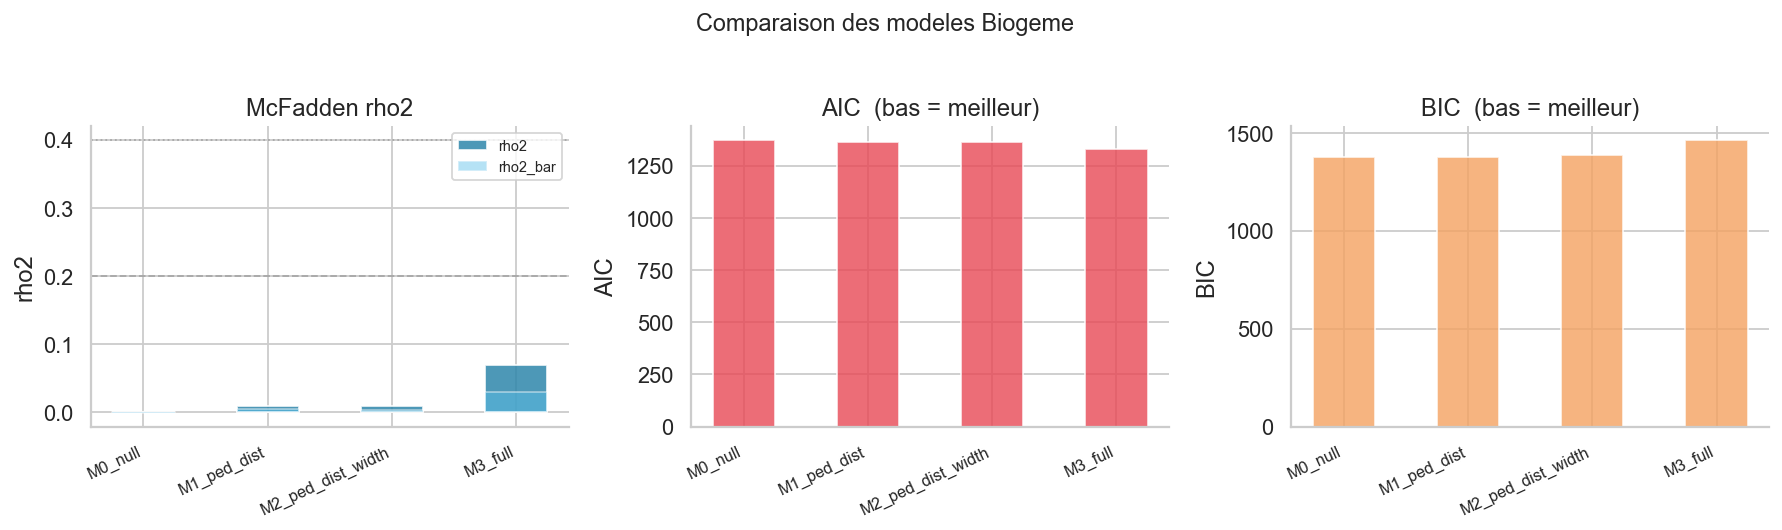

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
mnames = comparison.index.tolist()
x = np.arange(len(mnames))

ax = axes[0]
ax.bar(x, comparison['rho2'],     width=0.5, color=COLOR_ACC, alpha=0.85, label='rho2')
ax.bar(x, comparison['rho2_bar'], width=0.5, color='#5BC0EB', alpha=0.45, label='rho2_bar')
ax.set_xticks(x); ax.set_xticklabels(mnames, rotation=25, ha='right', fontsize=9)
ax.set_title('McFadden rho2'); ax.set_ylabel('rho2'); ax.legend(fontsize=8)
ax.axhline(0.2, ls='--', lw=1, color='gray', alpha=0.5, label='seuil 0.2')
ax.axhline(0.4, ls=':',  lw=1, color='gray', alpha=0.5, label='seuil 0.4')

ax = axes[1]
ax.bar(x, comparison['AIC'], width=0.5, color=COLOR_DEC, alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(mnames, rotation=25, ha='right', fontsize=9)
ax.set_title('AIC  (bas = meilleur)'); ax.set_ylabel('AIC')

ax = axes[2]
ax.bar(x, comparison['BIC'], width=0.5, color='#F4A261', alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(mnames, rotation=25, ha='right', fontsize=9)
ax.set_title('BIC  (bas = meilleur)'); ax.set_ylabel('BIC')

plt.suptitle('Comparaison des modeles Biogeme', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()


## 13 · Forest plot des coefficients — M2 & M3

Chaque barre = coefficient estime +/- IC 95 % robuste.
Bleu = effet positif (favorise acceleration), Rouge = effet negatif.

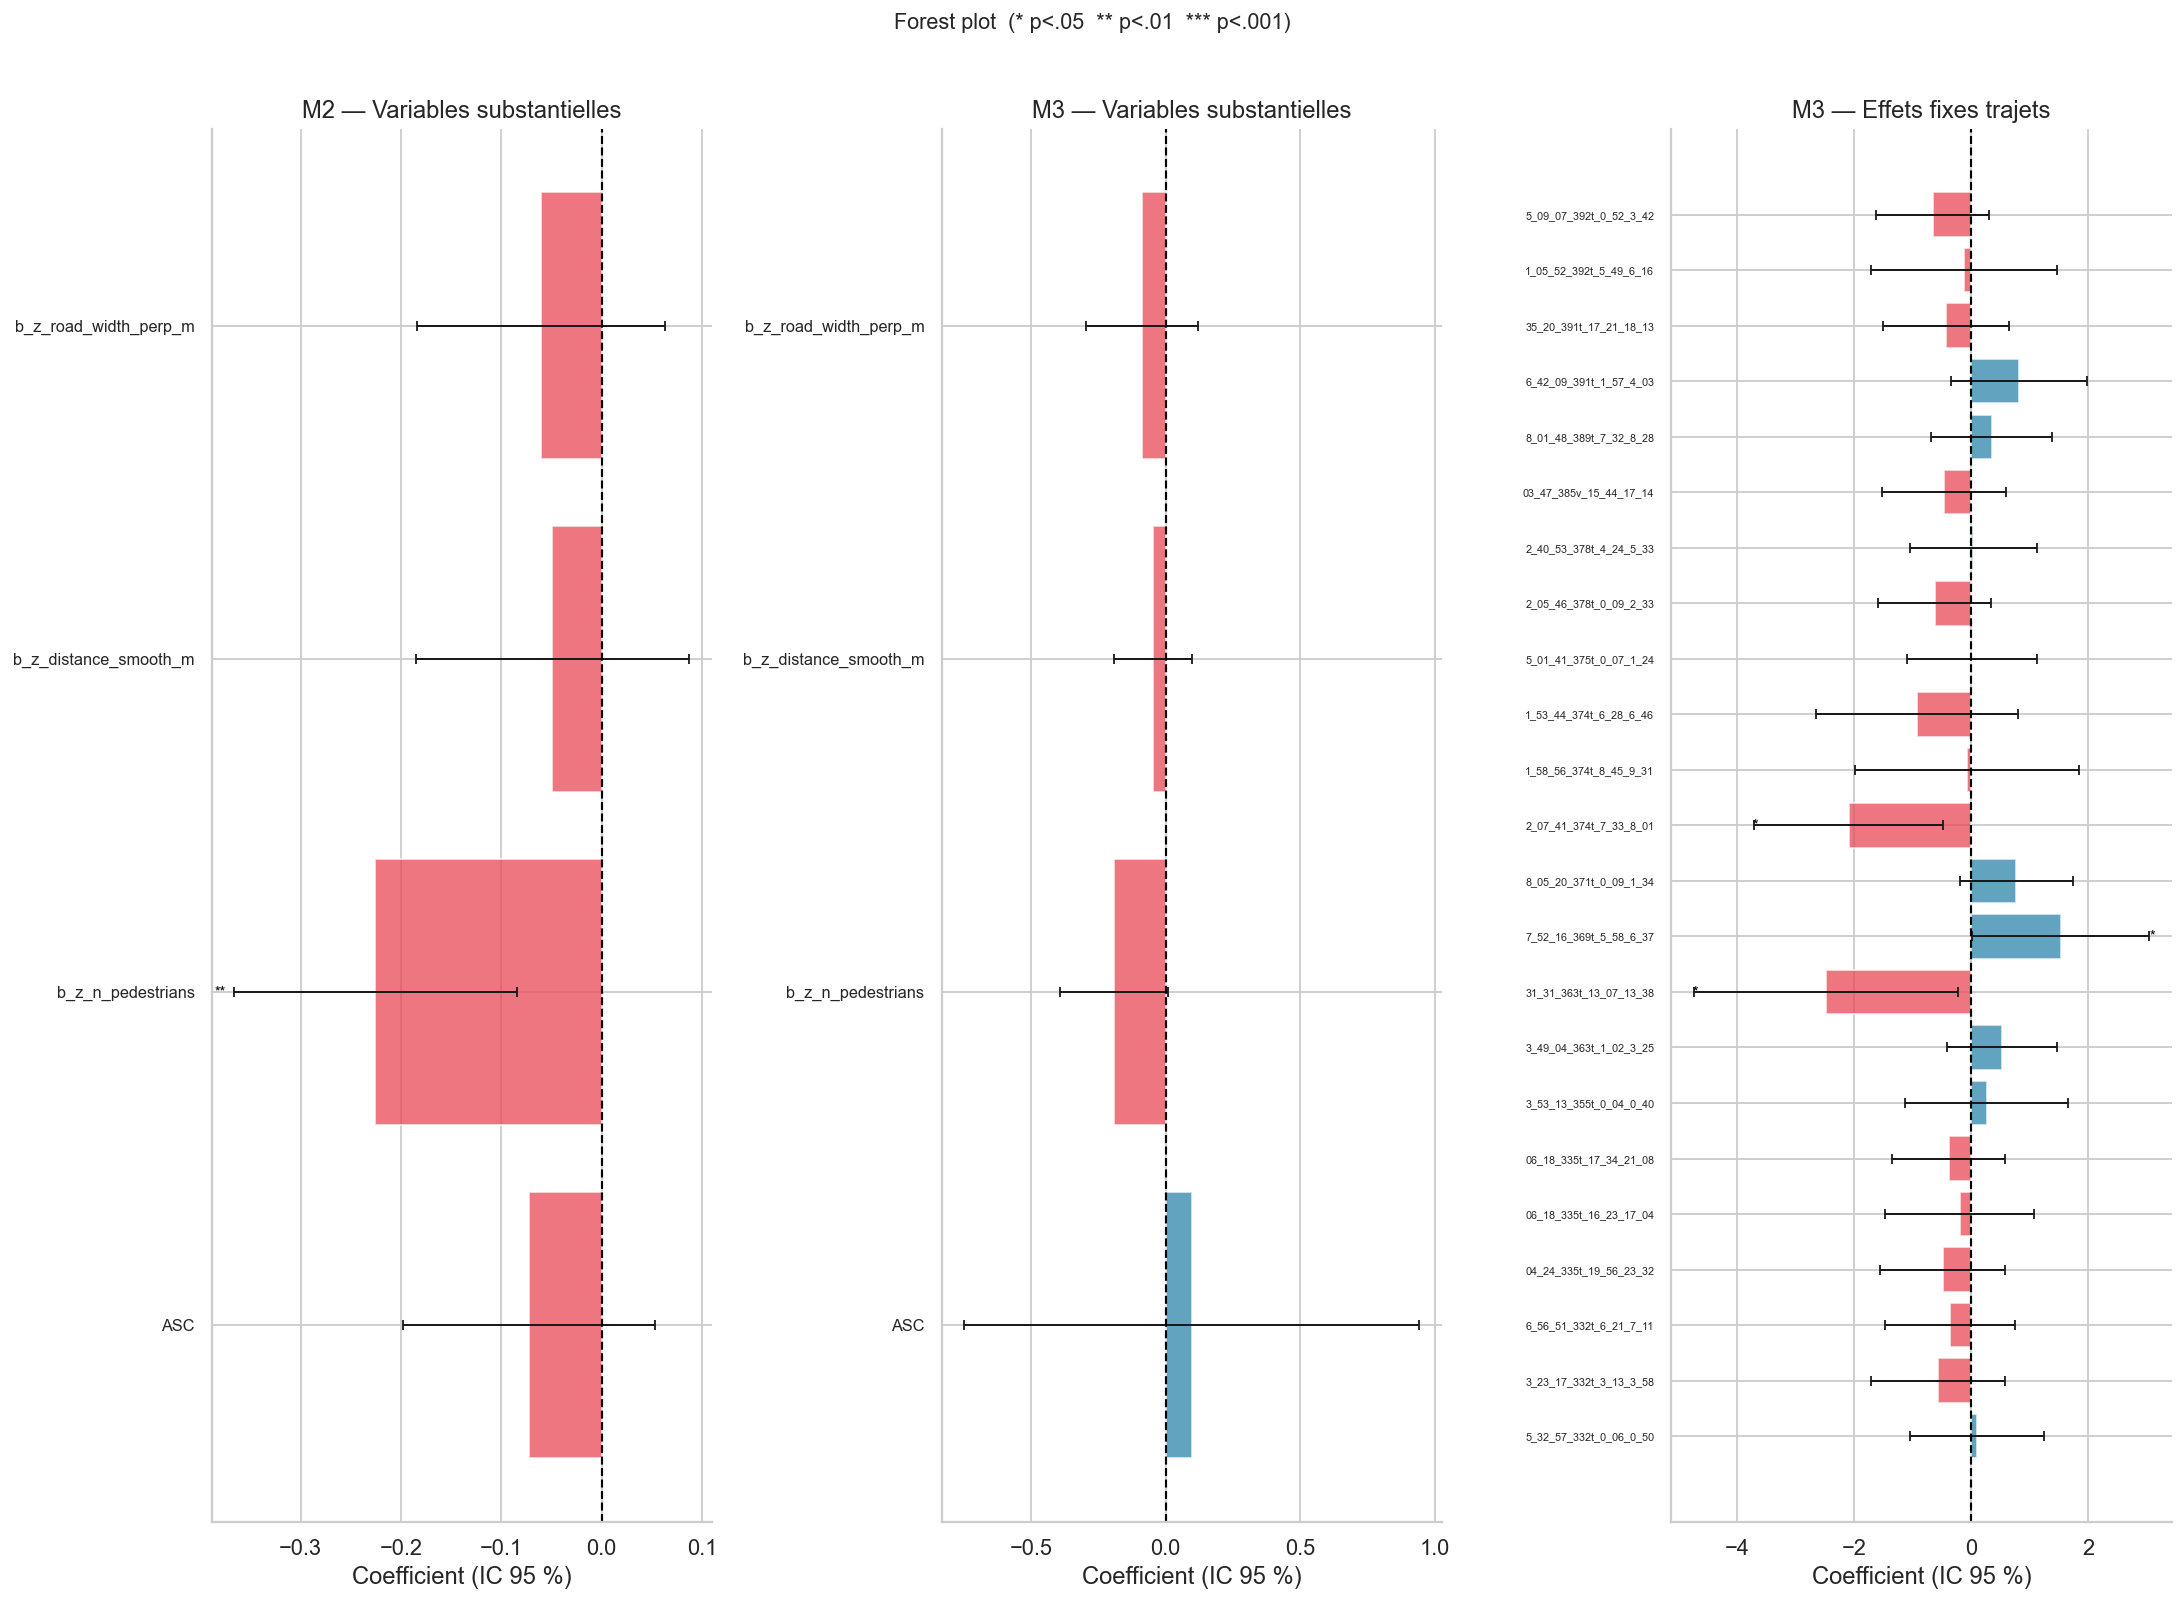

In [14]:
def forest_plot(ax, params_df, title, fontsize=9):
    coefs  = params_df['Value'].values.astype(float)
    ci95   = (1.96 * params_df['Robust std err.'].values.astype(float))
    pvals  = params_df['Robust p-value'].values.astype(float)
    names  = params_df['Name'].tolist()
    colors = [COLOR_ACC if c >= 0 else COLOR_DEC for c in coefs]
    y_pos  = range(len(names))

    ax.barh(list(y_pos), coefs, xerr=ci95, color=colors,
            alpha=0.75, capsize=3, error_kw={'lw': 1.1})
    ax.axvline(0, color='black', lw=1.2, ls='--')

    for i, p in enumerate(pvals):
        stars = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
        if stars:
            offset = 0.02 + ci95[i]
            ax.text(coefs[i] + np.sign(coefs[i]) * offset, i, stars,
                    va='center', fontsize=8, color='black')

    ax.set_yticks(list(y_pos))
    ax.set_yticklabels(names, fontsize=fontsize)
    ax.set_xlabel('Coefficient (IC 95 %)')
    ax.set_title(title)

# M2 — variables substantielles seulement
p2_df = all_params['M2_ped_dist_width'].copy()

# M3 — separer substantielles vs effets fixes
p3_df  = all_params['M3_full'].copy()
p3_main = p3_df[~p3_df['Name'].str.startswith('b_traj')].copy()
p3_fe   = p3_df[p3_df['Name'].str.startswith('b_traj')].copy()

fig, axes = plt.subplots(1, 3, figsize=(17, max(5, len(p3_fe)*0.4 + 3)))

forest_plot(axes[0], p2_df,    'M2 — Variables substantielles')
forest_plot(axes[1], p3_main,  'M3 — Variables substantielles')
forest_plot(axes[2], p3_fe,    'M3 — Effets fixes trajets',
            fontsize=max(6, 9 - len(p3_fe)//6))

axes[2].set_yticklabels(
    [n.replace('b_traj_', '')[-22:] for n in p3_fe['Name']],
    fontsize=max(6, 9 - len(p3_fe)//6))

plt.suptitle('Forest plot  (* p<.05  ** p<.01  *** p<.001)', fontsize=12, y=1.01)
plt.tight_layout(); plt.show()


## 14 · Effets marginaux (M2)

Formule du logit : `dP/dx_k = beta_k * P(acc) * (1 - P(acc))`

Evalues a la **moyenne** (z-scores = 0).
Les effets sont convertis en **unites originales** divisant par l'ecart-type.

P(accelerer) evaluee a la moyenne des variables : 0.4818


,Variable,beta_z,ME (unite originale)
0,n_pedestrians,-0.2254,-0.018698
1,distance_smooth_m,-0.0491,-0.003952
2,road_width_perp_m,-0.0602,-0.001072


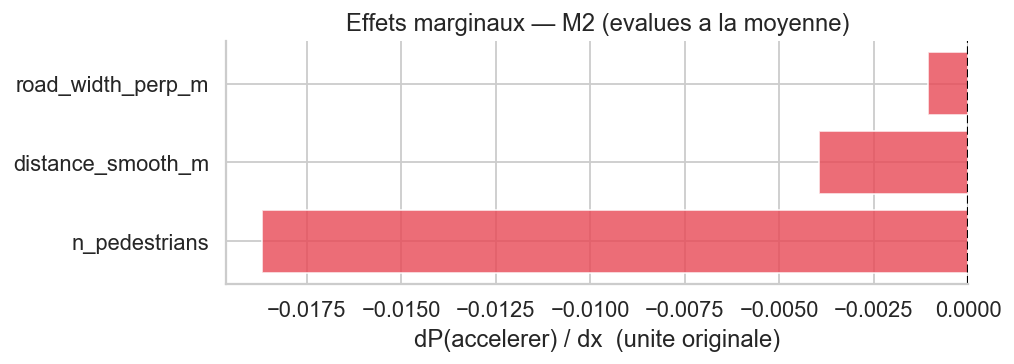

In [15]:
p2_betas = dict(zip(all_params['M2_ped_dist_width']['Name'],
                    all_params['M2_ped_dist_width']['Value'].astype(float)))

asc_val = p2_betas.get('ASC', 0.0)
P_mean  = 1 / (1 + np.exp(-asc_val))
print(f'P(accelerer) evaluee a la moyenne des variables : {P_mean:.4f}')

var_map = {
    'b_z_n_pedestrians':     ('n_pedestrians',     stds_['n_pedestrians']),
    'b_z_distance_smooth_m': ('distance_smooth_m', stds_['distance_smooth_m']),
    'b_z_road_width_perp_m': ('road_width_perp_m', stds_['road_width_perp_m']),
}

me_rows = []
for bname, (raw_name, sd) in var_map.items():
    beta_z = p2_betas.get(bname, float('nan'))
    me     = (beta_z / sd) * P_mean * (1 - P_mean)
    me_rows.append({'Variable': raw_name,
                    'beta_z':   round(beta_z, 4),
                    'ME (unite originale)': round(me, 6)})

me_df = pd.DataFrame(me_rows)
display(me_df)

fig, ax = plt.subplots(figsize=(8, 3))
colors_me = [COLOR_ACC if v >= 0 else COLOR_DEC
             for v in me_df['ME (unite originale)']]
ax.barh(me_df['Variable'], me_df['ME (unite originale)'],
        color=colors_me, alpha=0.8)
ax.axvline(0, color='black', lw=1.2, ls='--')
ax.set_xlabel('dP(accelerer) / dx  (unite originale)')
ax.set_title('Effets marginaux — M2 (evalues a la moyenne)')
plt.tight_layout(); plt.show()


## 15 · Courbes de probabilite predite (M2)

Chaque graphique fait varier **une variable** sur son etendue (p2-p98),
toutes les autres maintenues a leur moyenne (z=0).

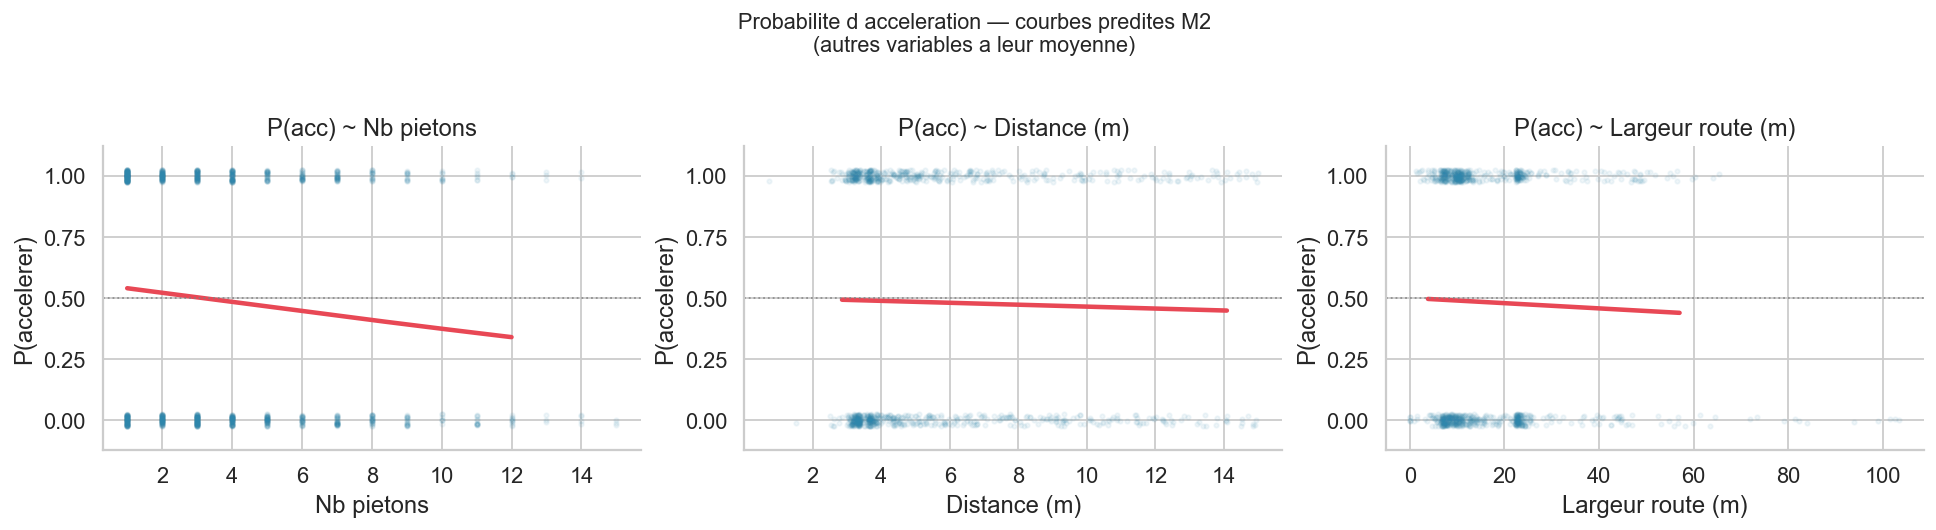

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

vars_plot = [
    ('z_n_pedestrians',     'n_pedestrians',     'Nb pietons'),
    ('z_distance_smooth_m', 'distance_smooth_m', 'Distance (m)'),
    ('z_road_width_perp_m', 'road_width_perp_m', 'Largeur route (m)'),
]

for ax, (z_var, raw_var, label) in zip(axes, vars_plot):
    x_raw = np.linspace(df_model[raw_var].quantile(0.02),
                        df_model[raw_var].quantile(0.98), 200)
    x_z   = (x_raw - means_[raw_var]) / stds_[raw_var]

    beta_foc = p2_betas.get(f'b_{z_var}', 0.0)
    V1_grid  = asc_val + beta_foc * x_z
    P_grid   = 1 / (1 + np.exp(-V1_grid))

    rng    = np.random.default_rng(42)
    jitter = rng.uniform(-0.025, 0.025, len(df_model))
    ax.scatter(df_model[raw_var], df_model['choice'] + jitter,
               alpha=0.07, s=6, color=COLOR_ACC)
    ax.plot(x_raw, P_grid, color=COLOR_DEC, lw=2.5)
    ax.axhline(0.5, color='gray', lw=1, ls=':', alpha=0.8)
    ax.set_ylim(-0.12, 1.12)
    ax.set_xlabel(label)
    ax.set_ylabel('P(accelerer)')
    ax.set_title(f'P(acc) ~ {label}')

plt.suptitle(
    'Probabilite d acceleration — courbes predites M2\n'
    '(autres variables a leur moyenne)',
    fontsize=12, y=1.02)
plt.tight_layout(); plt.show()


## 16 · Heatmap de probabilite predite — pietons x distance (M2)

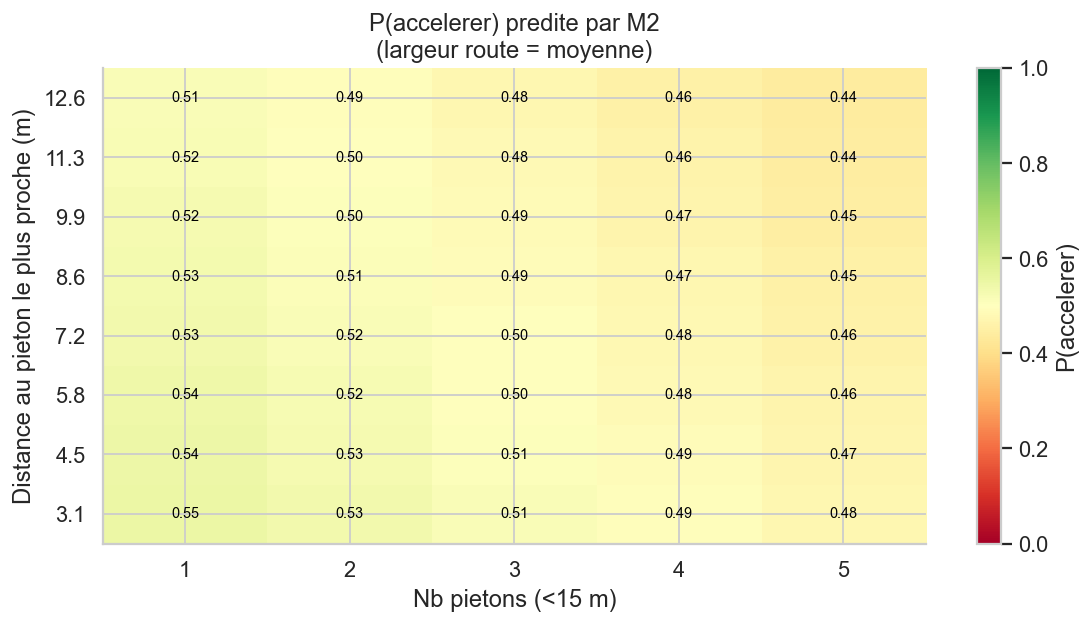

In [17]:
ped_vals  = np.array([1, 2, 3, 4, 5])
dist_vals = np.linspace(df_model['distance_smooth_m'].quantile(0.05),
                         df_model['distance_smooth_m'].quantile(0.95), 8)

grid_ped, grid_dist = np.meshgrid(ped_vals, dist_vals)

z_ped  = (grid_ped  - means_['n_pedestrians'])     / stds_['n_pedestrians']
z_dist = (grid_dist - means_['distance_smooth_m'])  / stds_['distance_smooth_m']

b_ped  = p2_betas.get('b_z_n_pedestrians',     0.0)
b_dist = p2_betas.get('b_z_distance_smooth_m', 0.0)

V1_grid = asc_val + b_ped * z_ped + b_dist * z_dist
P_grid  = 1 / (1 + np.exp(-V1_grid))

fig, ax = plt.subplots(figsize=(9, 5))
im = ax.imshow(P_grid, aspect='auto', origin='lower',
               cmap='RdYlGn', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label='P(accelerer)')

ax.set_xticks(range(len(ped_vals)))
ax.set_xticklabels(ped_vals)
ax.set_yticks(range(len(dist_vals)))
ax.set_yticklabels([f'{v:.1f}' for v in dist_vals])
ax.set_xlabel('Nb pietons (<15 m)')
ax.set_ylabel('Distance au pieton le plus proche (m)')
ax.set_title('P(accelerer) predite par M2\n(largeur route = moyenne)')

for i in range(len(dist_vals)):
    for j in range(len(ped_vals)):
        ax.text(j, i, f'{P_grid[i,j]:.2f}', ha='center', va='center',
                fontsize=8, color='black')

plt.tight_layout(); plt.show()


## 17 · Synthese & prochaines etapes

### Lecture des coefficients (logit, z-scores standardises)

| Signe beta | Interpretation |
|------------|----------------|
| beta > 0 | la variable **augmente** P(accelerer) |
| beta < 0 | la variable **reduit** P(accelerer) |

Les coefficients sont comparables entre eux (z-scores).

### Reperes pour rho2 McFadden

| rho2 | Qualite |
|------|--------|
| 0.10 – 0.20 | Acceptable |
| 0.20 – 0.40 | Bon |
| > 0.40 | Excellent |

### Pistes d extension

1. **Interaction** `z_distance x z_n_pedestrians` : la distance a-t-elle un effet different selon la densite ?
2. **Vitesse courante** `z_speed_kmh` comme covariable de controle (la vitesse initiale contraint la marge d acceleration)
3. **Mixed logit** (parametre aleatoire sur `n_pedestrians`) pour capturer l heterogeneite individuelle de la reaction
4. **Validation** : split train/test par trajet, courbe ROC, AUC
5. **Ordered logit** si on distingue fort freinage / maintien / forte acceleration (3 classes)
